# Advanced olfaction: plume tracking

This tutorial replays a time-varying odor plume, overlays it on rendered MuJoCo frames, and drives the fly with the plume-navigation controller ported from the v1 olfaction examples.

The HDF5 plume reader and plume-generation utilities require the optional olfaction dependencies. With `uv`, install them with `uv sync --extra olfaction --extra examples --extra dev`.

## Packaged plume data

FlyGym ships a short HDF5 plume dataset for tests and tutorials. `OdorPlumeWorld` maps fly sensor positions to plume grid cells and returns `NaN` when sensors move outside the plume domain.

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange

from flygym import assets_dir
from flygym.compose import OdorPlumeWorld
from flygym.examples.olfaction import PlumeNavigationController, PlumeNavigationTask
from flygym.examples.olfaction.common import add_world_camera, make_olfaction_fly
from flygym.examples.olfaction.simulate_plume_dataset import (
    generate_simulation_inputs,
    get_simulation_parameters,
    run_simulation as run_plume_simulation,
)
from flygym.utils.math import Rotation3D


output_dir = Path("outputs/advanced_olfaction")
output_dir.mkdir(parents=True, exist_ok=True)
plume_data_path = assets_dir / "olfaction/plume_short.hdf5"

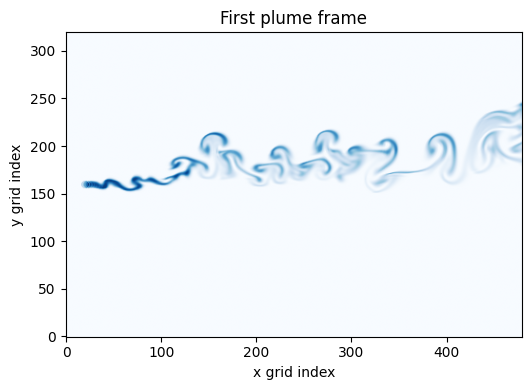

In [2]:
with h5py.File(plume_data_path, "r") as f:
    plume_frame = f["plume"][0]

fig, ax = plt.subplots(1, 1, figsize=(6, 4), tight_layout=True)
ax.imshow(plume_frame, origin="lower", cmap="Blues")
ax.set_title("First plume frame")
ax.set_xlabel("x grid index")
ax.set_ylabel("y grid index")
fig.savefig(output_dir / "plume_frame.png")

In [3]:
arena = OdorPlumeWorld(
    plume_data_path=plume_data_path,
    plume_simulation_fps=20,
    intensity_scale_factor=1.0,
)
positions = np.array([[0, 80, 1], [10, 80, 1], [52, 80, 1], [240, 160, 1]])
intensity = arena.get_olfaction(positions, time=0)

print(np.round(intensity, 4))
arena.close()

[[0.     0.4514 0.5884    nan]]


## Plume-navigation task

`PlumeNavigationTask` wraps a v2 `Simulation` and a `HybridTurningController`. The high-level action is a two-value descending drive; the task returns the familiar `(obs, reward, terminated, truncated, info)` tuple from `step()`.

In [4]:
main_camera_name = "birdeye_cam"
arena = OdorPlumeWorld(
    plume_data_path=plume_data_path,
    main_camera_name=main_camera_name,
    plume_simulation_fps=20,
)

fly = make_olfaction_fly(
    draw_sensor_markers=True,
    colorize=True,
)
camera = add_world_camera(
    arena,
    main_camera_name,
    pos=(0.50 * arena.arena_size[0], 0.15 * arena.arena_size[1], arena.arena_size[1]),
    euler=(np.deg2rad(15), 0, 0),
    fovy=60,
)

task = PlumeNavigationTask(
    fly=fly,
    arena=arena,
    cameras=[camera],
    spawn_position=(40, 80, 0.8),
    spawn_rotation=Rotation3D("quat", (0, 0, 0, -1)),
    camera_res=(160, 240),
    playback_speed=0.1,
    output_fps=25,
)

obs, info = task.reset()
print(sorted(obs))
print("odor shape:", obs["odor_intensity"].shape)

['cardinal_vectors', 'contact_forces', 'end_effectors', 'fly', 'fly_orientation', 'joints', 'odor_intensity']
odor shape: (1, 4)


The controller implements an encounter-driven state machine. Odor encounters make forward walking more likely, while intermittent turns are biased upwind or downwind based on recent encounter history.

In [5]:
controller = PlumeNavigationController(dt=task.timestep, random_seed=0)
encounter_threshold = 0.001
run_time = 0.2

obs_hist = []
state_hist = []
rendered_frames = []

for _ in trange(int(run_time / task.timestep), desc="Tracking plume"):
    encounter = np.nan_to_num(obs["odor_intensity"]).max() > encounter_threshold
    walking_state, dn_drive, debug_str = controller.decide_state(
        encounter_flag=bool(encounter),
        fly_heading=obs["fly_orientation"],
    )
    obs, reward, terminated, truncated, info = task.step(dn_drive)
    obs_hist.append(obs)
    state_hist.append(walking_state.value)

    frame = task.render()[0]
    if frame is not None:
        rendered_frames.append(frame)
    if terminated or truncated:
        break

print("Steps:", len(obs_hist))
print("Rendered frames:", len(rendered_frames))
print("Last controller state:", state_hist[-1])
print("Last debug string:", debug_str)

Tracking plume: 100%|██████████| 2000/2000 [00:04<00:00, 475.59it/s]

Steps: 2000
Rendered frames: 50
Last controller state: left turn
Last debug string: Wfreq=2.00  P(upwind)=0.83, turning UPWIND


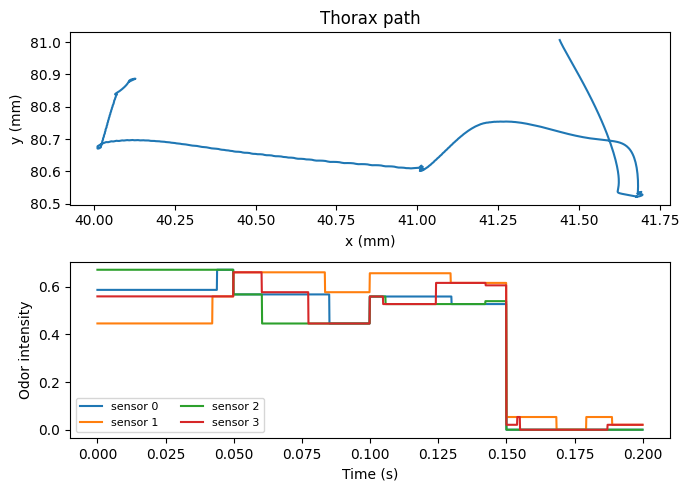

In [6]:
thorax_xy = np.array([obs["fly"][0, :2] for obs in obs_hist])
odor = np.array([obs["odor_intensity"][0] for obs in obs_hist])
time_grid = np.arange(len(obs_hist)) * task.timestep

fig, axes = plt.subplots(2, 1, figsize=(7, 5), tight_layout=True)
axes[0].plot(thorax_xy[:, 0], thorax_xy[:, 1])
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("x (mm)")
axes[0].set_ylabel("y (mm)")
axes[0].set_title("Thorax path")

for sensor_idx in range(odor.shape[1]):
    axes[1].plot(time_grid, odor[:, sensor_idx], label=f"sensor {sensor_idx}")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Odor intensity")
axes[1].legend(ncols=2, fontsize=8)

fig.savefig(output_dir / "plume_tracking_diagnostics.png")

## Birdseye plume video

`PlumeNavigationTask.render()` modifies the latest buffered `birdeye_cam` frame with the plume overlay. As in the turning-controller and olfaction-basics tutorials, `task.sim.renderer.show_in_notebook()` plays the in-memory rollout; then save the same buffer to disk before closing the HDF5-backed arena.

In [7]:
task.sim.renderer.show_in_notebook()
task.sim.renderer.save_video(output_dir / "plume_tracking_birdseye.mp4")
arena.close()

birdeye_cam This browser does not support the video tag.


## Generating a plume dataset

The tutorial above replays the packaged short dataset. To generate a new HDF5 plume, use the same helper functions as the `simulate_plume_dataset.py` example. The short run below is only a smoke test; longer datasets need more simulation time.

In [8]:
np.random.seed(0)
params = get_simulation_parameters(simulation_time=2)
(
    dt,
    arena_size,
    inflow_pos,
    inflow_radius,
    inflow_scaler,
    velocity_grid_size,
    smoke_grid_size,
    simulation_steps,
) = params

wind_hist, velocity, smoke, inflow = generate_simulation_inputs(
    simulation_steps,
    arena_size,
    inflow_pos,
    inflow_radius,
    inflow_scaler,
    velocity_grid_size,
    smoke_grid_size,
)
smoke_hist = run_plume_simulation(wind_hist, velocity, smoke, inflow, dt, arena_size)

print("Frames:", len(smoke_hist))
print("First-frame total smoke:", float(np.sum(smoke_hist[0])))

/home/user/flygym/.venv/lib/python3.12/site-packages/phiml/backend/torch/_torch_backend.py:875: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  return torch.sparse_csr_tensor(row_pointers, column_indices, values, shape, device=values.device)
/home/user/flygym/.venv/lib/python3.12/site-packages/phiml/backend/torch/_torch_backend.py:875: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  return torch.sparse_csr_tensor(row_poin

Frames: 2
First-frame total smoke: 10.153249740600586
